
# Checkpoint 4 — Limites, Desempenho de APIs e Streamlit

## Projeto aplicado de modelagem matemática

Este notebook analisa o comportamento do tempo médio de resposta de uma API conforme aumenta a quantidade de requisições por segundo. O objetivo é conectar **modelagem matemática, limites, programação em Python, visualização, aplicação interativa e tomada de decisão técnica**, mantendo o mesmo modelo no notebook e no Streamlit.

> **Contexto:** a infraestrutura possui capacidade estimada próxima de 50 requisições por segundo. O teste fornecido apresenta tempos de resposta que crescem fortemente quando a carga se aproxima desse valor.

### Organização

1. Contexto e dados do problema
2. Variáveis e domínios
3. Construção e justificativa do modelo
4. Análise de limites
5. Simulação computacional
6. Região crítica e referência de SLA
7. Aplicação Streamlit
8. Interpretação e tomada de decisão
9. Limitações e conclusão



## 1. Contexto e dados fornecidos

Os dados do teste de carga são:

| Requisições por segundo | Tempo médio de resposta (ms) |
|---:|---:|
| 10 | 25 |
| 20 | 33 |
| 30 | 50 |
| 35 | 67 |
| 40 | 100 |
| 45 | 200 |
| 48 | 500 |

O enunciado informa que a capacidade da infraestrutura está próxima de **50 req/s**.

O problema técnico é compreender o que acontece quando a carga se aproxima dessa capacidade e se a capacidade máxima estimada pode ser tratada como uma capacidade segura de operação.

O trabalho exige que o conceito de limite seja usado para investigar esse comportamento e que a aplicação Streamlit utilize exatamente o mesmo modelo matemático do notebook.


In [215]:

# Bibliotecas utilizadas no desenvolvimento do Projeto:
# - SymPy: definição simbólica da função e cálculo dos limites.
# - NumPy: geração de valores numéricos para as simulações e para o gráfico.
# - Pandas: organização dos resultados em tabela.
# - Matplotlib: construção do gráfico da função e dos pontos analisados.
# Para instalar pela primeira vez no VsCode as seguintes bibliotecas, 
# executar nessa celula os seguintes comandos %pip, e após isso, reiniciara a execução do notebook:
#(Aproximadamente 1 minuto de execução a 4 minutos de execução, dependendo da velocidade da internet e do computador)

"""%pip install sympy
%pip install numpy
%pip install pandas
%pip install matplotlib
%pip install ipython
%pip install streamlit"""

import sympy as sp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Math
import streamlit as st




## 2. Definição das variáveis e dos domínios

Definimos:

- `r`: variável independente, representando a carga de requisições por segundo (req/s).
- `T(r)`: variável dependente, representando o tempo médio de resposta (ms).

### Domínio matemático

O modelo escolhido terá denominador `50-r`. Portanto, matematicamente, a função não está definida em `r = 50`.

Assim, o domínio matemático da expressão racional é:

$$
D_{mat}=\mathbb{R}\setminus\{50\}
$$

### Domínio válido para o sistema

Para representar uma carga real, `r` não pode ser negativa. Além disso, valores iguais ou superiores a 50 req/s não devem ser interpretados diretamente pelo modelo como operação normal: em `50` há uma divisão por zero e, acima de `50`, a fórmula produziria tempos negativos, que não possuem significado físico.

Para a análise operacional, portanto, utilizaremos:

$$
0\leq r<50
$$

Esse cuidado é importante porque um valor matematicamente calculável não é necessariamente um estado fisicamente ou operacionalmente válido.


## 3. Construção do modelo matemático

Os dados apresentam um padrão muito característico: o tempo de resposta cresce de maneira cada vez mais rápida à medida que `r` se aproxima de 50 req/s.

Uma função racional simples que representa esse comportamento é:

$$
T(r)=\frac{1000}{50-r}
$$

A escolha é adequada por três motivos:

1. **Crescimento acelerado:** quando `r` aumenta, o denominador diminui e o tempo aumenta.
2. **Assíntota vertical:** em `r=50`, o denominador tende a zero, reproduzindo a ideia de saturação.
3. **Aderência aos dados:** a expressão reproduz exatamente os valores fornecidos no teste para os pontos apresentados.

Por exemplo:
$$
T(40)=\frac{1000}{50-40}=100\text{ ms}
$$

$$
T(45)=\frac{1000}{50-45}=200\text{ ms}
$$

$$
T(48)=\frac{1000}{50-48}=500\text{ ms}
$$
O modelo não afirma que o sistema real continuará obedecendo exatamente a essa lei em qualquer condição. Ele é uma aproximação matemática construída para representar o comportamento observado no intervalo do teste.

In [216]:

# Definição simbólica do modelo matemático.
# A variável r representa a carga em requisições por segundo.
# A constante 50 representa a capacidade estimada informada no enunciado.
r = sp.symbols("r", real=True)
T = 1000 / (50 - r)

print("Variável independente:", r)
print("Modelo T(r):", T)


Variável independente: r
Modelo T(r): 1000/(50 - r)



### Verificação do modelo com os dados do teste

A tabela abaixo permite verificar se a função escolhida reproduz os valores fornecidos.


In [217]:

# Dados observados no enunciado
# Diferença entre os tempos do enunciado e calculado seguindo a formula descrita.
dados_teste = pd.DataFrame({
    "Carga (req/s)": [10, 20, 30, 35, 40, 45, 48],
    "Tempo observado (ms)": [25, 33, 50, 67, 100, 200, 500]
})

# Avaliação numérica da mesma função para as cargas observadas.
dados_teste["Tempo pelo modelo (ms)"] = (
    1000 / (50 - dados_teste["Carga (req/s)"])
)

dados_teste["Diferença (ms)"] = (
    dados_teste["Tempo pelo modelo (ms)"] - dados_teste["Tempo observado (ms)"]
)

dados_teste


,Carga (req/s),Tempo observado (ms),Tempo pelo modelo (ms),Diferença (ms)
0,10,25,25.000000,0.000000
1,20,33,33.333333,0.333333
2,30,50,50.000000,0.000000
3,35,67,66.666667,-0.333333
4,40,100,100.000000,0.000000
5,45,200,200.000000,0.000000
6,48,500,500.000000,0.000000



Os valores coincidem com os dados fornecidos, exceto pequenas diferenças de arredondamento presentes nos valores 33 e 67 ms do enunciado. Isso reforça que a função racional escolhida é uma representação simples e coerente do conjunto de observações.



## 4. Análise matemática utilizando limites

O ponto central da análise é `r = 50`, pois ele representa a capacidade estimada da infraestrutura e também é o ponto em que o denominador da função se anula.

### 4.1 Limite pela esquerda

Como a operação normal é analisada para cargas menores que 50 req/s, o limite mais importante é:

$$
\boxed{\lim_{r\to50^-}\frac{1000}{50-r}}
$$

Quando `r` se aproxima de 50 pela esquerda, `50-r` é positivo e tende a zero. Consequentemente:

$$
\boxed{\lim_{r\to50^-}T(r)=+\infty}
$$

**Classificação:** infinito.

**Interpretação no gráfico:** a curva sobe sem limite quando se aproxima da reta vertical `r=50`.

**Interpretação no sistema:** pequenas aproximações adicionais à capacidade produzem aumentos muito grandes no tempo de resposta previsto. Portanto, a capacidade máxima teórica não deve ser confundida com uma capacidade segura.


In [218]:

# Cálculo simbólico do limite lateral pela esquerda.
limite_esquerda = sp.limit(T, r, 50, dir="-")
limite_esquerda


oo


### 4.2 Limite pela direita

Matematicamente também podemos investigar o que acontece quando `r` se aproxima de 50 pela direita:

$$
\boxed{lim_{r\to50^+}\frac{1000}{50-r}}
$$

Agora `50-r` é negativo e tende a zero. Portanto:

$$
\boxed{\lim_{r\to50^+}T(r)=-\infty}
$$

**Classificação:** infinito negativo.

Esse resultado é matematicamente válido para a expressão, mas **não é operacionalmente válido**: tempo de resposta negativo não existe fisicamente. Isso demonstra por que o domínio operacional precisa ser definido separadamente do domínio matemático.


In [219]:

# Cálculo simbólico do limite lateral pela direita.
limite_direita = sp.limit(T, r, 50, dir="+")
limite_direita


-oo


### 4.3 Limite em um ponto operacionalmente relevante

Também podemos verificar o comportamento em `r=45`, onde o modelo atinge 200 ms:

$$
\lim_{r\to45}T(r)=\frac{1000}{5}=200
$$

Esse limite é **finito** e igual ao valor da função, pois `T` é contínua em `r=45`.

A importância desse ponto é operacional: adotaremos **200 ms como SLA de referência para esta análise**. O enunciado pede uma referência de desempenho, mas não fornece um SLA específico; portanto, 200 ms é uma premissa explicitamente adotada pelo grupo para transformar o modelo em um critério de decisão.


In [220]:

# Limite bilateral em um ponto que não apresenta descontinuidade.
limite_45 = sp.limit(T, r, 45)
valor_45 = T.subs(r, 45)

print("limite quando r -> 45:", limite_45)
print("T(45):", valor_45)


limite quando r -> 45: 200
T(45): 200



### 4.4 Assíntota vertical

A assíntota vertical é:

$$
\boxed{r=50}
$$

Ela surge porque os limites laterais são infinitos e a função não está definida em `r=50`.

**Significado operacional:** no modelo, `r=50` representa uma barreira de saturação. A aproximação desse ponto indica perda progressiva da margem de capacidade e crescimento muito acentuado da latência. Em um sistema real, isso não significa que a latência literalmente se torna infinita; significa que o modelo está representando uma condição de saturação em que o desempenho se degrada fortemente.

A assíntota, portanto, funciona como um alerta matemático de que operar muito próximo da capacidade máxima é arriscado.



## 5. Simulação computacional

O enunciado exige simular pelo menos as cargas:

`10, 20, 30, 40, 45, 48, 49, 49,5 e 49,9 req/s`.

Os últimos valores são especialmente importantes porque mostram numericamente a aproximação da assíntota.


In [221]:

# Cargas obrigatórias. com acrescimo de 49.99 reqs/s para observar o comportamento da função.
cargas = np.array([10, 20, 30, 40, 45, 48, 49, 49.5, 49.9, 49.99])

# Avaliação numérica da função.
tempos = 1000 / (50 - cargas)

simulacao = pd.DataFrame({
    "Carga (req/s)": cargas,
    "Tempo previsto (ms)": tempos,
    "Tempo previsto (s)": tempos / 1000,
})

simulacao


,Carga (req/s),Tempo previsto (ms),Tempo previsto (s)
0,10.00,25.000000,0.025000
1,20.00,33.333333,0.033333
2,30.00,50.000000,0.050000
3,40.00,100.000000,0.100000
4,45.00,200.000000,0.200000
5,48.00,500.000000,0.500000
6,49.00,1000.000000,1.000000
7,49.50,2000.000000,2.000000
8,49.90,10000.000000,10.000000
9,49.99,100000.000000,100.000000



Os valores mostram claramente a aceleração do crescimento:

- em 45 req/s, o modelo prevê 200 ms;
- em 48 req/s, prevê 500 ms;
- em 49 req/s, prevê 1000 ms;
- em 49,5 req/s, prevê 2000 ms;
- em 49,9 req/s, prevê 10000 ms;
- em 49,99 req/s, prevê 100000 ms (100segundos). 

Portanto, uma pequena redução da distância para 50 req/s provoca um grande aumento no tempo previsto. Essa observação numérica é consistente com o limite simbólico `+∞` pela esquerda.


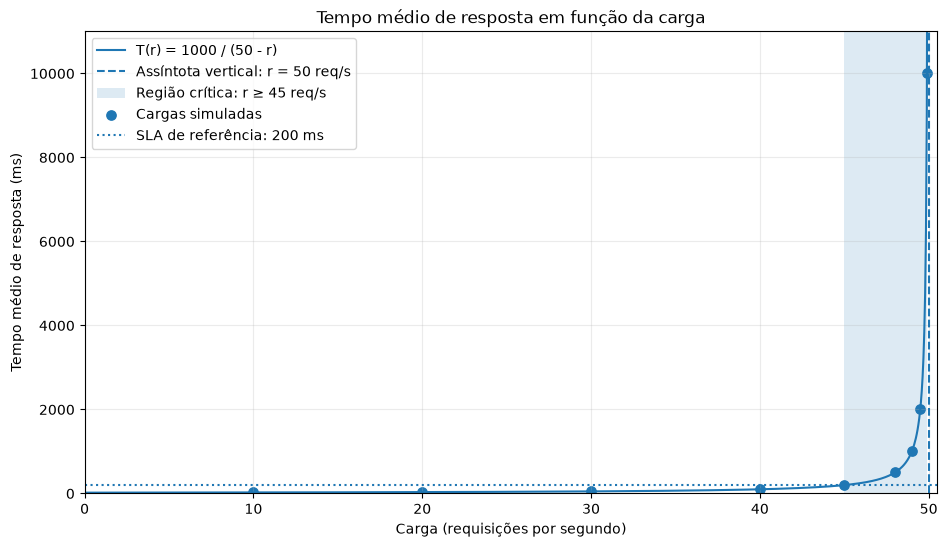

In [222]:

# Gráfico do modelo.
x = np.linspace(0, 49.99, 1000)
y = 1000 / (50 - x)

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(x, y, label="T(r) = 1000 / (50 - r)")
ax.axvline(50, linestyle="--", label="Assíntota vertical: r = 50 req/s")
ax.axvspan(45, 49.9, alpha=0.15, label="Região crítica: r ≥ 45 req/s")
ax.scatter(cargas, tempos, s=45, label="Cargas simuladas")
ax.axhline(200, linestyle=":", label="SLA de referência: 200 ms")

ax.set_title("Tempo médio de resposta em função da carga")
ax.set_xlabel("Carga (requisições por segundo)")
ax.set_ylabel("Tempo médio de resposta (ms)")
ax.set_xlim(0, 50.5)
ax.set_ylim(0, 11000)
ax.grid(True, alpha=0.25)
ax.legend()

plt.show()



## 6. Região crítica e capacidade segura

Para transformar o modelo em uma regra operacional, adotamos **200 ms como SLA de referência**.

Resolvendo:

$$
\frac{1000}{50-r}=200
$$

temos:

$$
1000=200(50-r)
$$

$$
1000=10000-200r
$$

$$
r=45
$$

Assim, no modelo, `45 req/s` é o ponto em que o SLA de 200 ms é atingido.

### Classificação adotada

- **Abaixo de 45 req/s:** condição abaixo da região crítica definida pelo SLA.
- **De 45 até abaixo de 50 req/s:** região crítica, porque o SLA é atingido/excedido e a carga se aproxima da assíntota.
- **50 req/s:** ponto de saturação do modelo; a função não é definida.
- **Acima de 50 req/s:** fora do domínio operacional adotado.

### Resposta à questão obrigatória
***Capacidade estimada de 50 requisições por segundo significa necessariamente que o sistema consegue operar normalmente com exatamente 50 requisições por
segundo? Fundamente a resposta utilizando o modelo construído.***

**Não.** A capacidade estimada de 50 req/s não significa que o sistema consiga operar normalmente com exatamente 50 req/s. No modelo, `r=50` é uma assíntota vertical e a função não possui valor finito nesse ponto. Além disso, o SLA de referência é atingido já em 45 req/s. Portanto, existe uma diferença clara entre **capacidade teórica máxima** e **capacidade operacional segura**.



## 7. Aplicação interativa em Streamlit

A aplicação deve usar exatamente o mesmo modelo:

$$
T(r)=\frac{1000}{50-r}
$$

O usuário informa a carga por meio de um controle interativo. A aplicação calcula o tempo previsto, mostra o gráfico, destaca a região crítica e compara o resultado com o SLA de referência.

Dessa maneira, o resultado matemático deixa de ser apenas uma expressão e passa a ser uma informação útil para uma pessoa responsável por operação, arquitetura ou infraestrutura: a pessoa pode testar diferentes cargas e observar quando o desempenho passa a ser preocupante.

A célula a seguir contém o **código completo do `app.py`** e também grava esse código em arquivo para facilitar a entrega.
O path serve para caso o Arquivo seja excluido ou não funcione, seja possível criá-lo novamente executando a célula abaixo



In [291]:
from pathlib import Path

app_code = '''import numpy as np
import matplotlib.pyplot as plt
import streamlit as st

CAPACIDADE = 50.0
SLA_MS = 200.0

st.set_page_config(
    page_title="Análise de desempenho da API",
    page_icon="📊",
    layout="wide",
)

st.markdown(
    """
    <style>

    * {
        font-family: 'Arial', sans-serif;
        font-size: 1.8rem;
    }

    .main-title {
        font-size: 3.5rem;
        font-weight: 700;
        margin-bottom: 0.2rem;
    }

    .subtitle {
        font-size: 2.5rem;
        margin-bottom: 1.5rem;
    }

    .formula {
        padding: 0.9rem 1rem;
        border-radius: 10px;
        text-align: center;
        font-size: 2rem;
        font-weight: 600;
        margin: 1rem 0;
    }

    .details {
        font-size: 1.7rem;
        margin-top: 0.5rem;
        background-color: #f0f0f0;
        padding: 0.8rem;
        border-radius: 8px;
    }
        
        /* Ver informações sobre o modelo */
        [data-testid="stExpander"] summary p {
        font-size: 1.8rem !important;
        font-weight: 600;
        #Comando acima para modificar o texto do botão do expandir

    </style>
    """,
    unsafe_allow_html=True,
)


def tempo_resposta(resposta):
    # Modelo: T(r) = 1000 / (50 - r)
    return 1000.0 / (CAPACIDADE - resposta)


st.markdown(
    '<div class="main-title">📊 Análise de desempenho da API</div>',
    unsafe_allow_html=True,
)

st.markdown(
    '<div class="subtitle">'
        'Modelo matemático para analisar o tempo de resposta conforme a carga aumenta.'
    '</div>',
    unsafe_allow_html=True,
)


with st.container(border=True):

    st.markdown("### Modelo matemático")

    st.markdown(
        '<div class="formula">'
            'T(r) = 1000 / (50 − r)'
        '</div>',
        unsafe_allow_html=True,
    )

    st.markdown(
        '<div class="details">'
            '<b>(R)</b> representa a carga em requisições por segundo (req/s) || ' 
            '<b> T(R) o tempo médio de resposta (ms).</b> || '
            ' A capacidade estimada é <b>50 req/s</b>.'
        '</div>',
        unsafe_allow_html=True,
    )


st.markdown("### 🎚️ Controle de carga")

r = st.slider(
    "Quantidade de requisições por segundo",
    min_value=0.0,
    max_value=49.99,
    value=40.0,
    step=0.1,
)


t = tempo_resposta(r)
distancia = CAPACIDADE - r


col1, col2, col3 = st.columns(3)

col1.metric(
    "Carga selecionada",
    f"{r:.1f} req/s"
)

col2.metric(
    "Tempo previsto",
    f"{t:.2f} ms"
)

col3.metric(
    "Margem até a capacidade",
    f"{distancia:.1f} req/s"
)


if r >= 48:

    st.error(
        "🔴 Região crítica: a carga está muito próxima da capacidade estimada. "
        "O modelo prevê crescimento muito acentuado do tempo de resposta."
    )

elif r >= 45:

    st.warning(
        "🟠 Atenção: a carga está na região em que o tempo previsto "
        "atinge ou ultrapassa o SLA de 200 ms."
    )

else:

    st.success(
        "🟢 A carga está abaixo da região crítica definida nesta análise."
    )


if t <= SLA_MS:

    st.info(
        f"Tempo previsto: **{t:.2f} ms** — "
        f"dentro do SLA de referência de **{SLA_MS:.0f} ms**."
    )

else:

    st.warning(
        f"Tempo previsto: **{t:.2f} ms** — "
        f"acima do SLA de referência de **{SLA_MS:.0f} ms**."
    )


st.markdown("### 📈 Comportamento do modelo")

# Evita desenhar o ponto r=50,
# onde a função não é definida.
x = np.linspace(0, 49.99, 800)
y = tempo_resposta(x)


fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    x,
    y,
    linewidth=2,
    label="T(r) = 1000 / (50 - r)"
)

ax.axvline(
    CAPACIDADE,
    linestyle="--",
    label="Assíntota: r = 50 req/s"
)

ax.axvspan(
    45,
    49.9,
    alpha=0.12,
    label="Região crítica: r ≥ 45"
)

ax.scatter(
    [r],
    [t],
    s=80,
    zorder=5,
    label="Carga selecionada"
)

ax.axhline(
    SLA_MS,
    linestyle=":",
    label="SLA: 200 ms"
)

ax.set_xlabel(
    "Carga (requisições por segundo)"
)

ax.set_ylabel(
    "Tempo médio de resposta (ms)"
)

ax.set_xlim(
    0,
    50.5
)

ax.set_ylim(
    0,
    min(max(550, t * 1.1), 1200)
)

ax.grid(
    True,
    alpha=0.25
)

ax.legend()

st.pyplot(fig)

plt.close(fig)


st.markdown("### 📌 Interpretação")

st.markdown(
    '<div class="details">'
        'Quanto mais a carga se aproxima de 50 req/s pela esquerda, menor fica o '
        'denominador da função e maior fica o tempo previsto. Portanto, operar '
        'continuamente perto da capacidade máxima reduz a margem de segurança.'
    '</div>',
    unsafe_allow_html=True,
)


with st.expander("Ver informações sobre o modelo"):
    
    st.markdown(
        '<div class="details">'
            '<b>Capacidade estimada:</b> 50 req/s<br>'
            '<b>SLA de referência:</b> 200 ms<br>'
            '<b>Limite crítico:</b> r = 45 req/s<br>'
            '<b>Assíntota vertical:</b> r = 50 req/s<br>'
            '<b>Domínio operacional:</b> 0 ≤ r &lt; 50'
        '</div>',
        unsafe_allow_html=True,
        
    )
    


st.markdown(
    '<div class="details">'
        '<b>Observação:</b> o modelo é uma aproximação matemática baseada nos dados '
        'fornecidos no teste de carga; não substitui medições reais de latência, '
        'throughput, erros, CPU, memória, banco de dados e comportamento sob concorrência.'
    '</div>',
    unsafe_allow_html=True,
)


'''

Path("app.py").write_text(
    app_code,
    encoding="utf-8"
)

print("Arquivo app.py gerado/atualizado com sucesso.")

Arquivo app.py gerado/atualizado com sucesso.



### Execução local

Depois de gerar o arquivo, execute no terminal:

```bash
streamlit run app.py
```
Caso não consiga carregar utilizando o comando acima, execute o comando alternativo:
```bash
py -m streamlit run app.py
```
```bash
OBS:
```
Verifique se o caminho do arquivo está dentro do caminho:
```bash
PS C:\Users\user\Downloads\CP4 Cálculo>
```
Antes de executar os comandos no terminal


## 8. Interpretação e tomada de decisão técnica

### a) Qual comportamento matemático caracteriza a saturação?

A saturação é caracterizada pelo crescimento não limitado de `T(r)` quando `r` se aproxima de 50 pela esquerda:

$$
\lim_{r\to50^-}T(r)=+\infty
$$

O denominador da função se aproxima de zero positivo e o tempo previsto cresce rapidamente.

### b) Qual região pode ser considerada crítica?

Com o SLA de referência de 200 ms adotado nesta análise, a região crítica começa em:

$$
r\ge45\text{ req/s}
$$

e se estende até a capacidade estimada de 50 req/s.

### c) Operar próximo da capacidade máxima é adequado?

Não como estratégia normal de operação. O modelo mostra que a margem entre 45 e 50 req/s é pequena, mas a degradação prevista é muito grande. Uma pequena variação na demanda pode levar a um aumento expressivo da latência.

### d) Existe diferença entre capacidade teórica e capacidade operacional segura?

Sim. `50 req/s` é a capacidade estimada associada à assíntota do modelo. Já a capacidade operacional segura precisa preservar margem para absorver picos, variabilidade e mudanças no comportamento do sistema. Neste estudo, o SLA já é atingido em 45 req/s.




## 9. Conclusão

O modelo racional

$$
T(r)=\frac{1000}{50-r}
$$

é coerente com os dados do teste e representa matematicamente a aceleração do tempo de resposta à medida que a carga se aproxima de 50 req/s.

O limite pela esquerda em 50 req/s é infinito positivo, indicando uma assíntota vertical e um comportamento de saturação. O limite pela direita também diverge, mas seu resultado negativo não possui interpretação física para tempo de resposta, reforçando a necessidade de distinguir domínio matemático de domínio operacional.

A análise mostra que **50 req/s não deve ser tratado como capacidade segura**. Com o SLA de referência de 200 ms adotado no projeto, a região crítica começa em 45 req/s. A recomendação é preservar margem de capacidade e combinar monitoramento com estratégias de escalabilidade e redução de carga conforme os gargalos reais forem identificados.

Por fim, o Streamlit transforma o modelo em uma ferramenta explorável: ao escolher uma carga, a pessoa responsável pela operação visualiza imediatamente o tempo previsto, a proximidade da capacidade e a relação com o SLA.
